In [14]:
import datetime as dt
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [16]:
def download_prices_yf(ticker: str, start_date: str, end_date: str) -> pd.DataFrame:
    df = yf.download(ticker, start=start_date, end=end_date, auto_adjust=False)
    if df.empty:
        raise RuntimeError(f"No data found for {ticker}")
    
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    return df

ticker = "AAPL"
start_date = "2010-01-01"
end_date = dt.date.today().strftime("%Y-%m-%d")

data = download_prices_yf(ticker, start_date, end_date)

close = data["Close"].astype(float)
high  = data["High"].astype(float)
low   = data["Low"].astype(float)
open_ = data["Open"].astype(float)

print(data.tail())

[*********************100%***********************]  1 of 1 completed

Price        Adj Close       Close        High         Low        Open   
Date                                                                     
2026-02-10  273.679993  273.679993  275.369995  272.940002  274.890015  \
2026-02-11  275.500000  275.500000  280.179993  274.450012  274.700012   
2026-02-12  261.730011  261.730011  275.720001  260.179993  275.589996   
2026-02-13  255.779999  255.779999  262.230011  255.449997  262.010010   
2026-02-17  263.880005  263.880005  266.290009  255.539993  258.049988   

Price         Volume  
Date                  
2026-02-10  34376900  
2026-02-11  51931300  
2026-02-12  81077200  
2026-02-13  56290700  
2026-02-17  58392700  


In [18]:
ret = close.pct_change().dropna()

log_ret = np.log(close / close.shift(1)).dropna()

N = len(ret)
dt_frac = 1.0 / 252.0   

print(f"Return statistics:\n{ret.describe()}\n")

Return statistics:
count    4054.000000
mean        0.001031
std         0.017754
min        -0.128647
25%        -0.007436
50%         0.000903
75%         0.010214
max         0.153289
Name: Close, dtype: float64



In [19]:
mu_hat = ret.mean() / dt_frac
print(f"Classical drift estimator   μ̂  = {mu_hat:.6f}  (annualized)")

Classical drift estimator   μ̂  = 0.259935  (annualized)


In [22]:
T_total = N * dt_frac

sig2_hat = (1.0 / (N - 1)) * ((ret**2).sum() / dt_frac) \
           - (T_total / (N - 1)) * mu_hat**2
sig_hat = np.sqrt(sig2_hat)

print(f"Volatility est.   σ̂  = {sig_hat:.6f}  (annualized)")
print(f"Variance est.    σ̂²  = {sig2_hat:.6f}\n")

Volatility est.   σ̂  = 0.281829  (annualized)
Variance est.    σ̂²  = 0.079427



In [23]:
T_days = len(high)
log_hl = np.log(high / low)

sig2_park_daily = (1.0 / (4.0 * np.log(2) * T_days)) * (log_hl**2).sum()
sig_parkinson = np.sqrt(sig2_park_daily * 252)

print(f"Parkinson volatility       σ_P  = {sig_parkinson:.6f}  (annualized)")


log_co = np.log(close / open_)

sig2_gk_daily = (1.0 / (2.0 * T_days)) * (log_hl**2).sum() \
                - ((2.0 * np.log(2) - 1.0) / T_days) * (log_co**2).sum()
sig_gk = np.sqrt(max(sig2_gk_daily, 0) * 252)

print(f"Garman-Klass volatility    σ_GK = {sig_gk:.6f}  (annualized)\n")

Parkinson volatility       σ_P  = 0.223926  (annualized)
Garman-Klass volatility    σ_GK = 0.224791  (annualized)



In [24]:
W = 30

roll_cls = ret.rolling(W).std() * np.sqrt(252)

hl2 = np.log(high / low)**2
roll_park = np.sqrt(hl2.rolling(W).mean() / (4 * np.log(2)) * 252)

co2 = np.log(close / open_)**2
gk_var = 0.5 * hl2.rolling(W).mean() - (2*np.log(2) - 1) * co2.rolling(W).mean()
roll_gk = np.sqrt(gk_var.clip(lower=0) * 252)


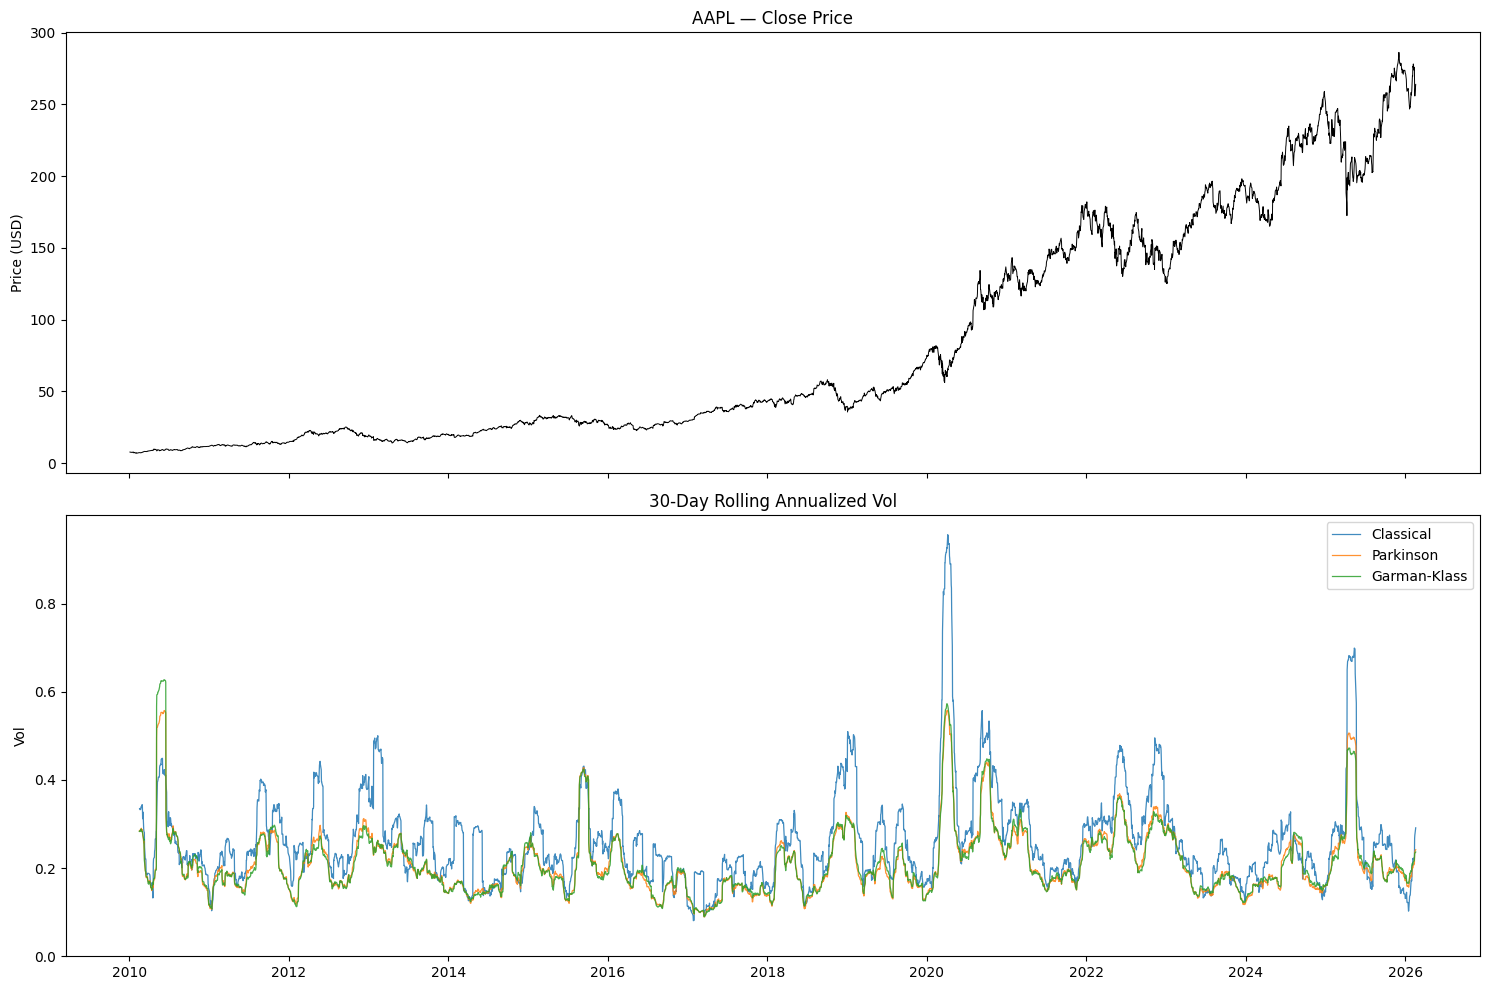

In [25]:
fig, ax = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

ax[0].plot(close, color="black", lw=0.7)
ax[0].set_title(f"{ticker} — Close Price")
ax[0].set_ylabel("Price (USD)")

ax[1].plot(roll_cls, label="Classical", lw=0.9, alpha=0.85)
ax[1].plot(roll_park, label="Parkinson", lw=0.9, alpha=0.85)
ax[1].plot(roll_gk, label="Garman-Klass", lw=0.9, alpha=0.85)
ax[1].set_title("30-Day Rolling Annualized Vol")
ax[1].set_ylabel("Vol")
ax[1].legend()
ax[1].set_ylim(bottom=0)

plt.tight_layout()
plt.savefig("step3_rolling_vol.png", dpi=150)
plt.show()

Using: AAPL


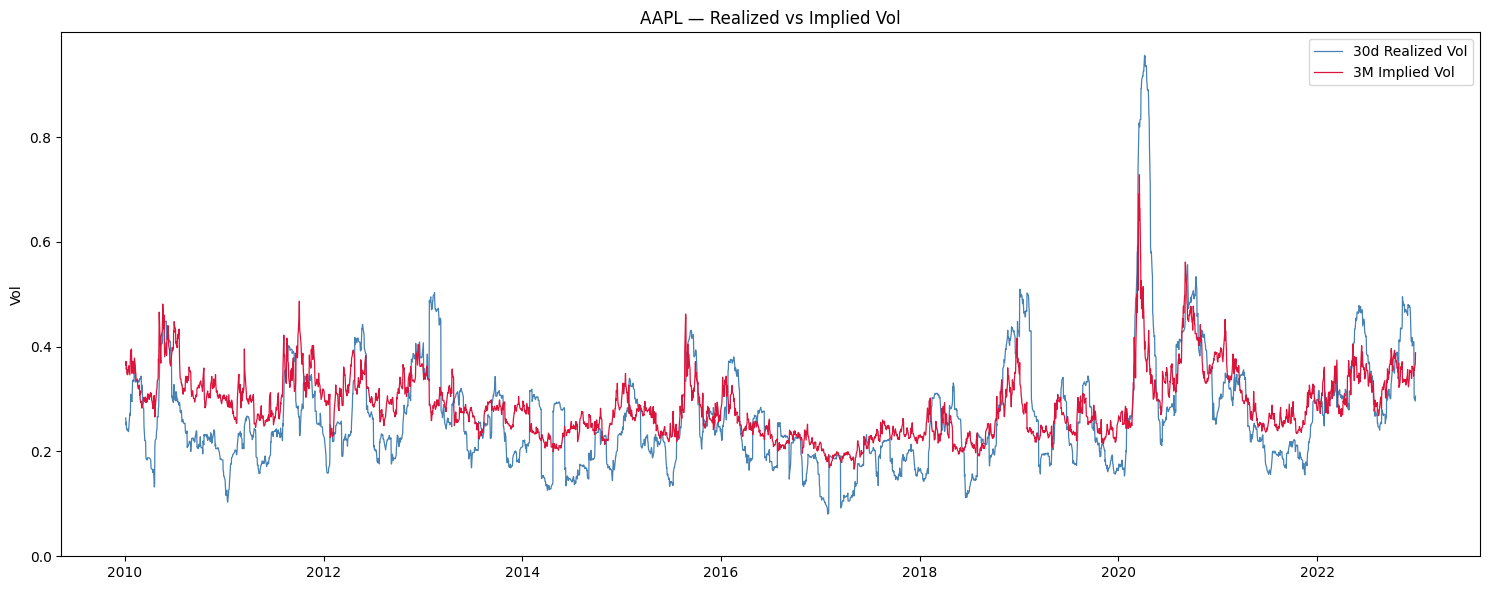

Correlation: 0.6746


In [26]:
from skfolio.datasets import load_sp500_dataset, load_sp500_implied_vol_dataset

prices_sp = load_sp500_dataset()
iv_df = load_sp500_implied_vol_dataset()

common = sorted(set(prices_sp.columns) & set(iv_df.columns))
tk = "AAPL" if "AAPL" in common else common[0]
print(f"Using: {tk}")

rv = prices_sp[tk].pct_change().rolling(30).std() * np.sqrt(252)
iv = iv_df[tk].dropna()

idx = rv.dropna().index.intersection(iv.index)
rv, iv = rv.loc[idx], iv.loc[idx]

fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(rv, label="30d Realized Vol", lw=0.9, color="steelblue")
ax.plot(iv, label="3M Implied Vol", lw=0.9, color="crimson")
ax.set_title(f"{tk} — Realized vs Implied Vol")
ax.set_ylabel("Vol")
ax.legend()
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.savefig("step3_rv_vs_iv.png", dpi=150)
plt.show()

print(f"Correlation: {rv.corr(iv):.4f}")